# MDA + RBF

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bluemath_tk.datamining.lhs import LHS
from bluemath_tk.datamining.mda import MDA
from bluemath_tk.interpolation.rbf import RBF
from utils.plotting import plot_variable_combinations

## Workflow overview

This notebook combines three complementary techniques:

1. **Latin Hypercube Sampling (LHS)** generates a broad set of combinations of the input variables.
2. **Maximum Dissimilarity Algorithm (MDA)** selects a smaller, representative subset of those combinations.
3. **Radial Basis Function (RBF)** interpolation uses the selected cases to estimate the target variable throughout the complete parameter space.

## 1. Latin Hypercube Sampling (LHS)

LHS is a stratified sampling method designed to cover a multidimensional parameter space efficiently. The range of each variable is divided into equally probable intervals, and one value is sampled from every interval. The samples from the different variables are then combined without repetition.

Here, LHS generates combinations of significant wave height ($H_s$), peak period ($T_p$), and wave direction ($Dir$). Compared with independent random sampling, it provides more uniform coverage using the same number of points. The fixed seed makes the experiment reproducible.

In [2]:
dimensions_names = ["Hs", "Tp", "Dir"]
lower_bounds = [0, 3, 0]
upper_bounds = [7, 20, 360]
num_samples = 5000

lhs = LHS(num_dimensions=len(dimensions_names), seed=0)
data = lhs.generate(
    dimensions_names=dimensions_names,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    num_samples=num_samples,
)
data

,Hs,Tp,Dir
0,6.304708,16.881283,74.445050
1,1.559577,9.814235,87.918282
2,0.878351,7.284920,126.392859
3,0.457891,13.540626,153.575803
4,0.956400,9.949486,56.611465
...,...,...,...
4995,4.594856,7.112538,290.918683
4996,3.119144,15.155431,237.694065
4997,1.815617,19.624995,22.539618
4998,4.265459,11.671846,316.059564


### Physical restriction: wave steepness

LHS explores the numerical bounds without knowing whether every combination is physically realistic. We therefore calculate the deep-water wave steepness

$$S = \frac{H_s}{L_0} = \frac{2\pi H_s}{gT_p^2},$$

where $L_0=gT_p^2/(2\pi)$ is the deep-water wavelength and $g=9.81\,\mathrm{m\,s^{-2}}$. Samples with $S>0.05$ are removed before applying MDA.

In [3]:
max_steepness = 0.05
steepness = (2 * np.pi * data["Hs"]) / (9.81 * data["Tp"] ** 2)
data = data.loc[steepness <= max_steepness].reset_index(drop=True)

In [4]:
num_centers = 100
dir_vars = ["Dir"]

mda = MDA(num_centers=num_centers)
nearest_centroids_idxs, nearest_centroids_df = mda.fit_predict(
    data=data,
    directional_variables=dir_vars,
)

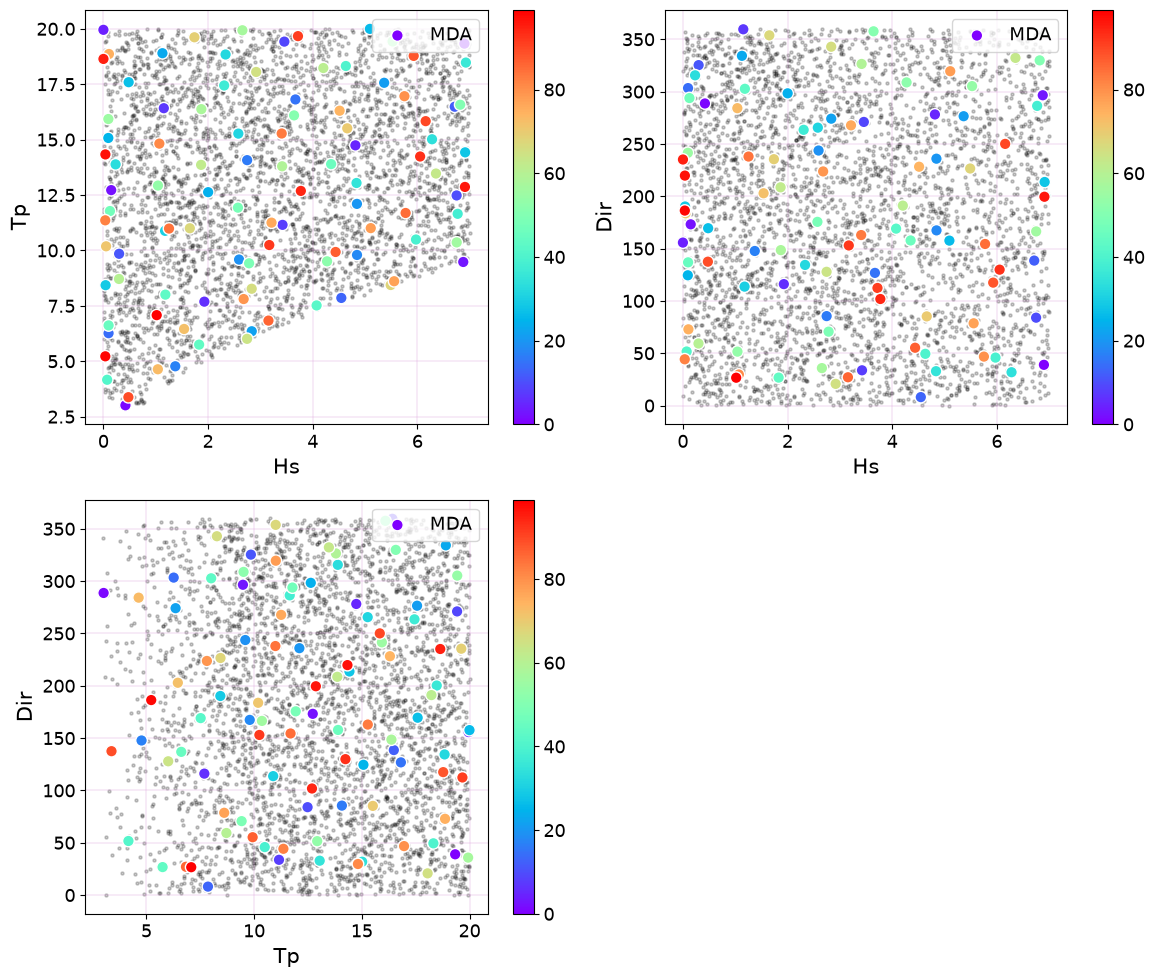

In [5]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(mda.data, vars, mda.centroids, labels="MDA")

## 2. Maximum Dissimilarity Algorithm (MDA)

MDA reduces the LHS dataset to a prescribed number of representative cases. Starting from an initial case, it iteratively selects the point that is most dissimilar from those already selected. This preserves the extremes and spreads the centroids across the available parameter space.

Wave direction is declared as a directional variable because $0^\circ$ and $360^\circ$ represent the same direction and must be treated as neighboring values. The selected centroids are the cases for which the target response is assumed to be known.

For this example, the target response is a quantity proportional to wave-energy flux:

$$EF = H_s^2 T_p.$$

It is evaluated at the MDA centroids and later used to train the RBF interpolator.

In [6]:
target = pd.DataFrame(
    {
        "EF": mda.centroids.Hs.values**2 * mda.centroids.Tp.values,
    }
)

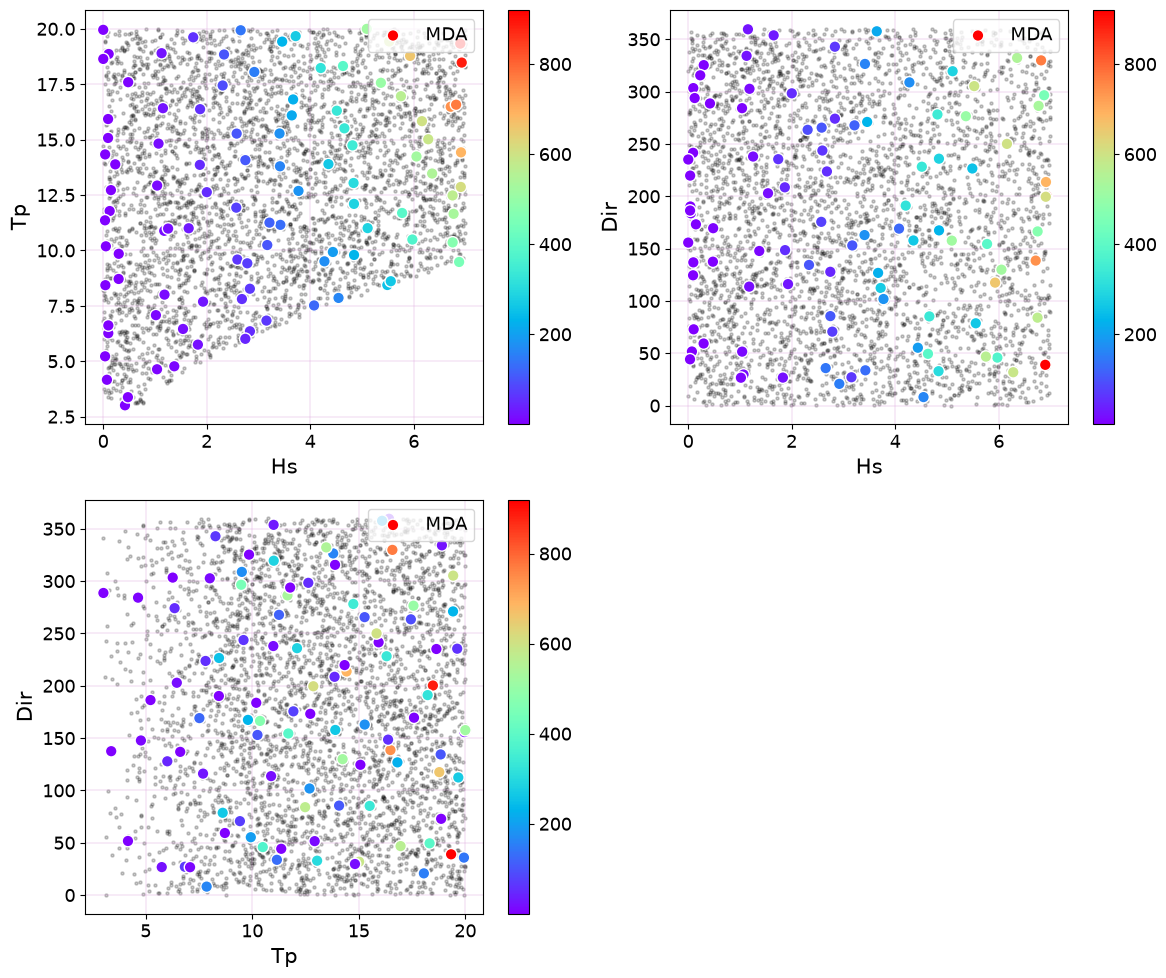

In [7]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(
    mda.data, vars, mda.centroids, sel_color=target.EF, labels="MDA"
)

## 3. Radial Basis Function (RBF) interpolation

RBF interpolation reconstructs a continuous response from the values known at the MDA centroids. The prediction at each point is obtained from radially symmetric basis functions whose influence depends on the distance to each centroid.

The input variables and target are normalized during fitting so that variables with different units and scales contribute consistently. The kernel-width parameter is updated iteratively, and the fitted model predicts $EF$ for every physically valid LHS sample.

In [8]:
dataset = data  # Data to interpolate

subset = mda.centroids  # Parameters to fit RBF
target = target  # Response to fit RBF

subset_directional_variables = ["Dir"]
target_directional_variables = []

In [9]:
rbf = RBF()

predictions = rbf.fit_predict(
    subset_data=subset,
    subset_directional_variables=subset_directional_variables,
    target_data=target,
    target_directional_variables=target_directional_variables,
    normalize_target_data=True,
    dataset=dataset,
    num_workers=4,
    iteratively_update_sigma=True,
)
print(predictions.head())

           EF
0  670.622017
1   24.620318
2    4.811208
3   -1.284723
4    9.282469


In [10]:
predictions

,EF
0,670.622017
1,24.620318
2,4.811208
3,-1.284723
4,9.282469
...,...
3981,665.133158
3982,397.948898
3983,145.860190
3984,66.752419


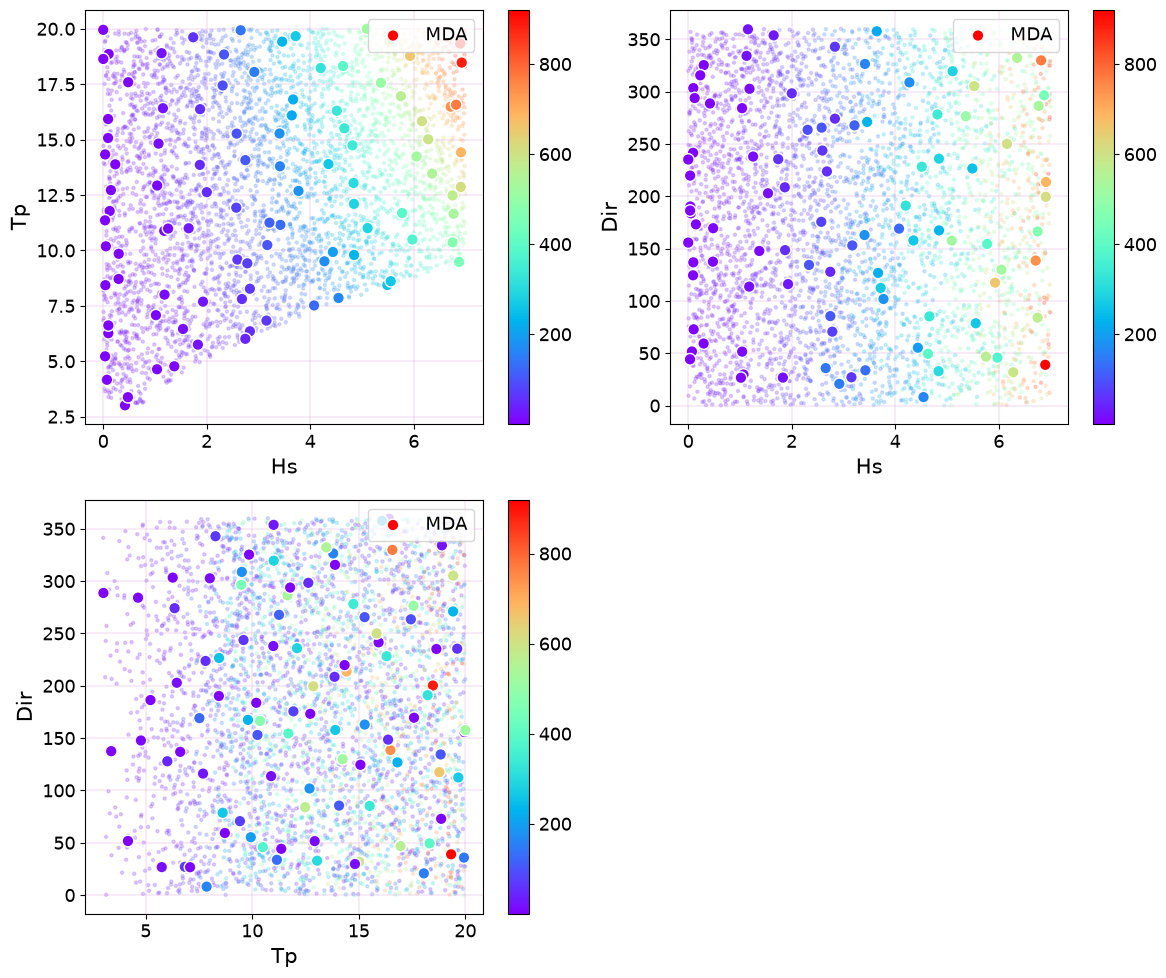

In [11]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(
    mda.data,
    vars,
    mda.centroids,
    data_color=predictions.EF,
    sel_color=target.EF,
    labels="MDA",
)

## 4. Model error: Root Mean Square Error

The Root Mean Square Error (RMSE) compares the RBF prediction with the analytical value of $EF$. Lower values indicate a more accurate reconstruction; larger errors receive more weight because the differences are squared.

$$\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(EF_i^{\mathrm{RBF}}-EF_i^{\mathrm{real}}\right)^2}$$


In [12]:
RMSE = np.sqrt(np.mean((predictions.EF - (data.Hs**2 * data.Tp)) ** 2))

## 5. Selecting the number of MDA centroids

The complete MDA–RBF workflow is repeated for different numbers of centroids. Plotting RMSE against the number of selected cases reveals the trade-off between computational cost and interpolation accuracy. A useful choice is near the point where adding more centroids produces only a small reduction in RMSE.

In [13]:
num_centers_explore = np.arange(10, 600, 50)

In [14]:
RMSE = []
rbf = RBF()
rbf.set_logger_name(name="RBF-file", level="WARN", console=False)

for d in num_centers_explore:
    # MDA
    dir_vars = ["Dir"]

    mda = MDA(num_centers=d)
    nearest_centroids_idxs, nearest_centroids_df = mda.fit_predict(
        data=data,
        directional_variables=dir_vars,
    )

    target = pd.DataFrame(
        {
            "EF": mda.centroids.Hs.values**2 * mda.centroids.Tp.values,
        }
    )

    # RBF

    subset = mda.centroids  # Parameters to fit RBF
    target = target  # Response to fit RBF

    predictions = rbf.fit_predict(
        subset_data=subset,
        subset_directional_variables=subset_directional_variables,
        target_data=target,
        target_directional_variables=target_directional_variables,
        normalize_target_data=True,
        dataset=dataset,
        num_workers=4,
        iteratively_update_sigma=True,
    )

    RMSE.append(np.sqrt(np.mean((predictions.EF - (data.Hs**2 * data.Tp)) ** 2)))

Text(0, 0.5, 'RMSE')

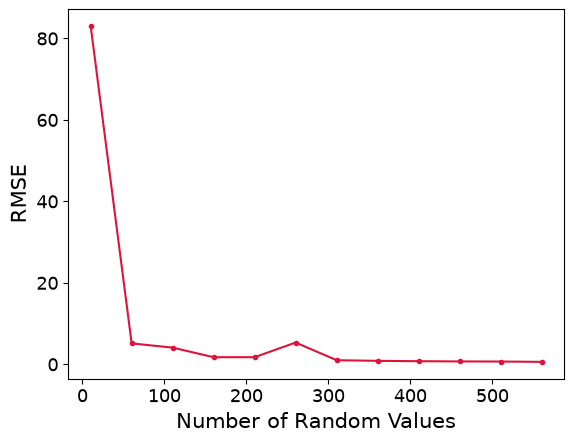

In [15]:
plt.plot(num_centers_explore, RMSE, ".-", color="crimson")
plt.xlabel("Number of Random Values")
plt.ylabel("RMSE")